In [91]:
import os
import re
import random
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import *
from sentence_transformers import SentenceTransformer
import joblib
import matplotlib.pyplot as plt
import umap.umap_ as umap
import plotly.express as px

## Data Load

In [6]:
SEED = 42

DATA_PATH = "../data/processed/Product Data - CleanEn.csv"

TEXT_COLS = ["Name_EN", "Description_EN", "Composition_EN"]
TARGET_COL = "Item_Quality_Code"

MAX_LEN = 128
MIN_FREQ = 2
BATCH_SIZE = 64
EMBED_DIM = 128
HIDDEN_DIM = 128
EPOCHS = 10
LR = 1e-3

DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")
df.head(5)

Device: cpu


,SKU,Name_EN,Composition_EN,Description_EN,Gender,Grammage,Weight_net,Item_Quality_Code,Item_Quality_Code_desc,Tree
0,GAB/00311/L335,Long White Cooking Apron with Front Pocket,100% Cotton/Cotton twill,"Long white cooking apron with front pocket, 60...",Unisex,180,0.160,OTF,Technical clothing_-_Aprons,Gadgets
1,GAB/00512/01,Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",Unisex,140,0.069,TOZB,Bags_-_Cotton / shopping bags,Gadgets
2,GAB/00512/02,Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",Unisex,140,0.069,TOZB,Bags_-_Cotton / shopping bags,Gadgets
3,GAB/00512/03,Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",Unisex,140,0.069,TOZB,Bags_-_Cotton / shopping bags,Gadgets
4,GAB/00512/04,Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",Unisex,140,0.069,TOZB,Bags_-_Cotton / shopping bags,Gadgets


In [7]:
df_model = df.copy()
df_model = df_model[df_model[TARGET_COL].notna()].copy()

for col in TEXT_COLS:
    df_model[col] = df_model[col].fillna("").astype(str)

df_model["text"] = df_model[TEXT_COLS].agg(" ".join, axis=1)
df_model["text"] = df_model["text"].str.strip()
df_model = df_model[df_model["text"] != ""].copy()

print(df_model.shape)
df_model[[TARGET_COL, "text"]].head()

(273067, 11)


,Item_Quality_Code,text
0,OTF,Long White Cooking Apron with Front Pocket Lon...
1,TOZB,Shopping Bag with Short Handles Handles: 35 x ...
2,TOZB,Shopping Bag with Short Handles Handles: 35 x ...
3,TOZB,Shopping Bag with Short Handles Handles: 35 x ...
4,TOZB,Shopping Bag with Short Handles Handles: 35 x ...


In [38]:
class_counts = df_model[TARGET_COL].value_counts()
rare_classes = class_counts[class_counts < 2].index
df_model = df_model[~df_model[TARGET_COL].isin(rare_classes)].copy()
print(df_model.shape)
label_encoder = LabelEncoder()
df_model["label"] = label_encoder.fit_transform(df_model[TARGET_COL])
num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

(273065, 12)
Number of classes: 197


### Split test/train/val

In [39]:
RANDOM_STATE = SEED

y_all = df_model["label"].values
idx_all = np.arange(len(df_model))

idx_trainval, idx_test = train_test_split(
    idx_all,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

val_size = 0.20 / 0.90  # ~0.2222
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=val_size,
    random_state=RANDOM_STATE,
    stratify=y_all[idx_trainval],
)

## Baseline TF-IDF

In [40]:
tfidf_cols = ["text", "Gender", "Tree", "Grammage", "Weight_net"]

X_full = df_model[tfidf_cols].copy()
y_full = df_model["label"].values

X_train_tfidf = X_full.iloc[idx_train]
X_val_tfidf   = X_full.iloc[idx_val]
X_test_tfidf  = X_full.iloc[idx_test]

y_train_tfidf = y_full[idx_train]
y_val_tfidf   = y_full[idx_val]
y_test_tfidf  = y_full[idx_test]

text_col = "text"
cat_cols = ["Gender", "Tree"]
num_cols = ["Grammage", "Weight_net"]

### Training

In [41]:
text_transformer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True,
)

cat_transformer = OneHotEncoder(handle_unknown="ignore")
numeric_transformer = StandardScaler()

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_transformer, text_col),
        ("cat", cat_transformer, cat_cols),
        ("num", numeric_transformer, num_cols),
    ]
)

clf_tfidf = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearSVC(C=1.0)),
])

clf_tfidf.fit(X_train_tfidf, y_train_tfidf)

pred_val = clf_tfidf.predict(X_val_tfidf)
pred_test = clf_tfidf.predict(X_test_tfidf)

print(classification_report(y_val_tfidf, pred_val, zero_division=0))
print("VAL Acc:", accuracy_score(y_val_tfidf, pred_val), "VAL F1:", f1_score(y_val_tfidf, pred_val, average="macro"))

print(classification_report(y_test_tfidf, pred_test, zero_division=0))
print("TEST Acc:", accuracy_score(y_test_tfidf, pred_test), "TEST F1:", f1_score(y_test_tfidf, pred_test, average="macro"))

/mnt/Dane_Ubuntu/AI Projects/E-commerce_category_classification/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.89      0.69      0.77        35
           2       1.00      0.87      0.93        15
           3       0.60      1.00      0.75         3
           4       1.00      0.40      0.57         5
           5       1.00      1.00      1.00         8
           6       0.94      0.98      0.96       300
           7       0.90      0.90      0.90        21
           8       1.00      0.50      0.67         8
           9       1.00      0.75      0.86         4
          10       0.87      0.93      0.90        28
          11       1.00      0.80      0.89         5
          12       0.20      0.50      0.29         2
          13       0.90      0.99      0.94        75
          14       0.96      0.99      0.97        79
          15       1.00      0.86      0.92         7
          16       0.93      0.97      0.95        92
          17       0.46    

In [42]:
#Save model
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(clf_tfidf, "../models/tfidf_pipeline.joblib")
joblib.dump(label_encoder, "../models/tfidf_label_encoder.joblib")

['../models/tfidf_label_encoder.joblib']

## Baseline Simple NLP

### Tokenization

In [28]:
def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return text.strip().split()

X_all_text = df_model["text"].values
y_all = df_model["label"].values

X_train_text = X_all_text[idx_train]
X_val_text   = X_all_text[idx_val]
X_test_text  = X_all_text[idx_test]

counter = Counter()
for text in X_train_text:
    counter.update(tokenize(text))

vocab = {
    "PAD": 0,
    "UNK": 1,
}
for word, count in counter.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

print("Vocab size:", len(vocab))

Vocab size: 13815


### Modeling

In [23]:
def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    if len(ids) > max_len:
        ids = ids[:max_len]

    attention_mask = [1] * len(ids)
    while len(ids) < max_len:
        ids.append(vocab["<PAD>"])
        attention_mask.append(0)

    return ids, attention_mask

class ProductDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, attention_mask = encode_text(
            self.texts[idx], self.vocab, self.max_len
        )
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.float),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds_mlp = ProductDataset(X_train_text, y_all[idx_train], vocab, MAX_LEN)
val_ds_mlp   = ProductDataset(X_val_text,   y_all[idx_val],   vocab, MAX_LEN)
test_ds_mlp  = ProductDataset(X_test_text,  y_all[idx_test],  vocab, MAX_LEN)

train_loader_mlp = DataLoader(train_ds_mlp, batch_size=BATCH_SIZE, shuffle=True)
val_loader_mlp   = DataLoader(val_ds_mlp,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_mlp  = DataLoader(test_ds_mlp,  batch_size=BATCH_SIZE, shuffle=False)

class SimpleNLPClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        embedded = self.embedding(input_ids)
        mask = attention_mask.unsqueeze(-1)
        embedded = embedded * mask
        summed = embedded.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = summed / lengths
        logits = self.classifier(pooled)
        return logits

model_mlp = SimpleNLPClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=num_classes,
).to(DEVICE)

class_counts = np.bincount(y_all[idx_train], minlength=num_classes)
class_weights = 1.0 / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

criterion_mlp = nn.CrossEntropyLoss(weight=class_weights)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=LR)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, all_labels, all_preds

### Training Loop

In [24]:
best_val_f1 = 0.0
MODEL_PATH_MLP = os.path.join(MODEL_DIR, "simple_nlp_classifier.pt")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model_mlp, train_loader_mlp, optimizer_mlp, criterion_mlp
    )
    val_loss, val_acc, val_f1, val_labels, val_preds = evaluate(
        model_mlp, val_loader_mlp, criterion_mlp
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(
            {
                "model_state_dict": model_mlp.state_dict(),
                "vocab": vocab,
                "label_classes": label_encoder.classes_.tolist(),
                "vocab_size": len(vocab),
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "num_classes": num_classes,
                "max_len": MAX_LEN,
                "text_cols": TEXT_COLS,
                "target_col": TARGET_COL,
            },
            MODEL_PATH_MLP,
        )

Epoch 01 | Train loss: 2.8506 | Train acc: 0.5177 | Train F1: 0.3269 | Val loss: 1.3935 | Val acc: 0.7955 | Val F1: 0.5832
Saved best MLP baseline to ../src/models/simple_nlp_classifier.pt
Epoch 02 | Train loss: 1.1551 | Train acc: 0.7757 | Train F1: 0.5958 | Val loss: 0.8641 | Val acc: 0.8779 | Val F1: 0.7049
Saved best MLP baseline to ../src/models/simple_nlp_classifier.pt
Epoch 03 | Train loss: 0.7366 | Train acc: 0.8550 | Train F1: 0.7061 | Val loss: 0.6733 | Val acc: 0.9128 | Val F1: 0.7610
Saved best MLP baseline to ../src/models/simple_nlp_classifier.pt
Epoch 04 | Train loss: 0.5138 | Train acc: 0.8949 | Train F1: 0.7760 | Val loss: 0.5887 | Val acc: 0.9310 | Val F1: 0.7924
Saved best MLP baseline to ../src/models/simple_nlp_classifier.pt
Epoch 05 | Train loss: 0.3877 | Train acc: 0.9192 | Train F1: 0.8202 | Val loss: 0.5690 | Val acc: 0.9469 | Val F1: 0.8128
Saved best MLP baseline to ../src/models/simple_nlp_classifier.pt
Epoch 06 | Train loss: 0.2994 | Train acc: 0.9356 | Tra

## E5 embeddings

### Fetching embeddings

In [10]:
texts = ("passage: " + df_model["text"]).tolist()

labels_cat = df_model[TARGET_COL].astype("category")
y_ids = labels_cat.cat.codes.values
id2label = dict(enumerate(labels_cat.cat.categories))
label2id = {v: k for k, v in id2label.items()}
num_classes = len(id2label)

embed_model_name = "intfloat/multilingual-e5-base"
embed_model = SentenceTransformer(embed_model_name, device=DEVICE)

X_emb = embed_model.encode(
    texts,
    batch_size=64,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
    device=DEVICE,
)
emb_dim = X_emb.shape[1]
print(X_emb.shape)

os.makedirs("../data/embeddings", exist_ok=True)
np.save("../data/embeddings/e5_all_cpu.npy", X_emb)

KeyboardInterrupt: 

In [11]:
X_emb_all = np.load("../data/embeddings/e5_all_cpu.npy")
X_emb_all.shape[1]

768

In [16]:
meta_df = df_model[cat_cols + num_cols].copy()

for col in cat_cols:
    meta_df[col] = meta_df[col].fillna("missing").astype(str)

for col in num_cols:
    meta_df[col] = pd.to_numeric(meta_df[col], errors="coerce")

train_num_medians = meta_df.iloc[idx_train][num_cols].median()
meta_df[num_cols] = meta_df[num_cols].fillna(train_num_medians)

meta_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

X_meta_train = meta_preprocessor.fit_transform(meta_df.iloc[idx_train])
X_meta_val   = meta_preprocessor.transform(meta_df.iloc[idx_val])
X_meta_test  = meta_preprocessor.transform(meta_df.iloc[idx_test])

if hasattr(X_meta_train, "toarray"):
    X_meta_train = X_meta_train.toarray()
    X_meta_val = X_meta_val.toarray()
    X_meta_test = X_meta_test.toarray()

X_train_emb = X_emb_all[idx_train]
X_val_emb   = X_emb_all[idx_val]
X_test_emb  = X_emb_all[idx_test]

X_train_e5_meta = np.concatenate([X_train_emb, X_meta_train.astype(np.float32)], axis=1)
X_val_e5_meta   = np.concatenate([X_val_emb,   X_meta_val.astype(np.float32)], axis=1)
X_test_e5_meta  = np.concatenate([X_test_emb,  X_meta_test.astype(np.float32)], axis=1)

joblib.dump(meta_preprocessor, "../models/e5_meta_preprocessor.joblib")

print("Embeddings:", X_train_emb.shape)
print("Meta:", X_meta_train.shape)
print("Concat:", X_train_e5_meta.shape)

Embeddings: (191145, 768)
Meta: (191145, 8)
Concat: (191145, 776)


### Dataloaders

In [62]:
y_all = df_model["label"].values

X_train_emb = X_emb_all[idx_train]
X_val_emb   = X_emb_all[idx_val]
X_test_emb  = X_emb_all[idx_test]

y_train = y_all[idx_train]
y_val   = y_all[idx_val]
y_test  = y_all[idx_test]

class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return {
            "features": self.X[idx],
            "label": self.y[idx],
        }

train_ds_e5 = EmbeddingDataset(X_train_e5_meta, y_train)
val_ds_e5   = EmbeddingDataset(X_val_e5_meta,   y_val)
test_ds_e5  = EmbeddingDataset(X_test_e5_meta,  y_test)

train_loader_e5 = DataLoader(train_ds_e5, batch_size=BATCH_SIZE, shuffle=True)
val_loader_e5   = DataLoader(val_ds_e5, batch_size=BATCH_SIZE, shuffle=False)
test_loader_e5  = DataLoader(test_ds_e5, batch_size=BATCH_SIZE, shuffle=False)

### Modeling

In [82]:
class E5Classifier(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim,
        num_classes,
        dropout=0.3
    ):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.output = nn.Linear(
            hidden_dim,
            num_classes
        )
    def forward(
        self,
        features,
        return_embeddings=False
    ):
        hidden_repr = self.hidden(features)
        logits = self.output(hidden_repr)
        if return_embeddings:
            return logits, hidden_repr

        return logits

emb_dim = X_train_e5_meta.shape[1]
num_classes = len(label_encoder.classes_)

model_e5 = E5Classifier(
    in_dim=emb_dim,
    hidden_dim=HIDDEN_DIM,
    num_classes=num_classes,
).to(DEVICE)

#### Grid search

In [93]:
from itertools import product
import copy

E5_EPOCHS = 2

param_grid = {
    "hidden_dim": [128, 256],
    "dropout": [0.2, 0.3],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-5, 1e-4],
}

grid_results = []

input_dim = X_train_e5_meta.shape[1]
num_classes = len(label_encoder.classes_)

class_counts = np.bincount(y_train, minlength=num_classes)
class_weights = 1.0 / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

train_ds_e5 = EmbeddingDataset(X_train_e5_meta, y_train)
val_ds_e5 = EmbeddingDataset(X_val_e5_meta, y_val)
test_ds_e5 = EmbeddingDataset(X_test_e5_meta, y_test)

train_loader_e5 = DataLoader(train_ds_e5, batch_size=BATCH_SIZE, shuffle=True)
val_loader_e5 = DataLoader(val_ds_e5, batch_size=BATCH_SIZE, shuffle=False)
test_loader_e5 = DataLoader(test_ds_e5, batch_size=BATCH_SIZE, shuffle=False)

for hidden_dim, dropout, lr, weight_decay in product(
    param_grid["hidden_dim"],
    param_grid["dropout"],
    param_grid["lr"],
    param_grid["weight_decay"]
):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model_e5 = E5Classifier(
        in_dim=input_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        dropout=dropout
    ).to(DEVICE)

    criterion_e5 = nn.CrossEntropyLoss(weight=class_weights)
    optimizer_e5 = torch.optim.AdamW(
        model_e5.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler_e5 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_e5,
        mode="max",
        factor=0.5,
        patience=1,
    )

    best_val_f1 = -1.0
    best_val_acc = -1.0
    best_state_dict = None

    for epoch in range(1, E5_EPOCHS + 1):
        train_loss, train_acc, train_f1 = train_one_epoch_e5(
            model_e5, train_loader_e5, optimizer_e5, criterion_e5
        )

        val_loss, val_acc, val_f1, _, _ = evaluate_e5(
            model_e5, val_loader_e5, criterion_e5
        )

        scheduler_e5.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state_dict = copy.deepcopy(model_e5.state_dict())

    grid_results.append({
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": weight_decay,
        "val_f1": best_val_f1,
        "val_acc": best_val_acc,
        "state_dict": best_state_dict,
    })

grid_results_df = pd.DataFrame([
    {k: v for k, v in row.items() if k != "state_dict"}
    for row in grid_results
]).sort_values(by=["val_f1", "val_acc"], ascending=False).reset_index(drop=True)

grid_results_df

,hidden_dim,dropout,lr,weight_decay,val_f1,val_acc
0,256,0.2,0.0010,0.00001,0.529720,0.771098
1,256,0.2,0.0010,0.00010,0.523943,0.763829
2,256,0.3,0.0010,0.00001,0.494253,0.719572
3,256,0.3,0.0010,0.00010,0.486957,0.731657
4,128,0.2,0.0010,0.00010,0.454462,0.710637
5,256,0.2,0.0005,0.00010,0.449285,0.726164
6,256,0.2,0.0005,0.00001,0.448373,0.723234
7,128,0.2,0.0010,0.00001,0.448069,0.701719
8,256,0.3,0.0005,0.00010,0.435920,0.701536
9,128,0.3,0.0010,0.00010,0.433840,0.678465


In [19]:
DROPOUT = 0.2
HIDDEN_DIM = 512
LR = 0.001
WEIGHT_DECAY = 0.00001

In [31]:
def train_one_epoch_e5(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in loader:
        features = batch["features"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1


def evaluate_e5(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            features = batch["features"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            logits = model(features)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, all_labels, all_preds

### Weights

In [83]:
class_counts = np.bincount(y_train, minlength=num_classes)
class_weights = 1.0 / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

criterion_e5 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_e5 = torch.optim.Adam(model_e5.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler_e5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_e5, mode="max", factor=0.5, patience=1)

### Training loop

In [84]:
MODEL_DIR = "../models"
best_val_f1 = 0.0
MODEL_PATH_MLP_E5 = os.path.join(MODEL_DIR, "e5_embeddings_classifier.pt")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": [],
    "train_acc": [],
    "val_acc": [],
}

for epoch in range(1, EPOCHS + 15):
    train_loss, train_acc, train_f1 = train_one_epoch_e5(
        model_e5, train_loader_e5, optimizer_e5, criterion_e5
    )
    val_loss, val_acc, val_f1, val_labels, val_preds = evaluate_e5(
        model_e5, val_loader_e5, criterion_e5
    )
    scheduler_e5.step(val_f1)

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(
        {
            "model_state_dict": model_e5.state_dict(),
            "input_dim": X_train_e5_meta.shape[1],
            "vocab": vocab,
            "label_classes": label_encoder.classes_.tolist(),
            "embed_model_name": "intfloat/multilingual-e5-base",
            "vocab_size": len(vocab),
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "num_classes": num_classes,
            "max_len": MAX_LEN,
            "text_cols": TEXT_COLS,
            "target_col": TARGET_COL,
            "use_meta_features": True,
            "cat_cols": ["Gender", "Tree"],
            "num_cols": ["Grammage", "Weight_net"],
        },
        MODEL_PATH_MLP_E5,
        )

Epoch 01 | Train loss: 3.5960 | Train acc: 0.4373 | Train F1: 0.1810 | Val loss: 2.0036 | Val acc: 0.7301 | Val F1: 0.4437
Epoch 02 | Train loss: 1.6920 | Train acc: 0.6901 | Train F1: 0.4313 | Val loss: 1.2207 | Val acc: 0.7966 | Val F1: 0.5580
Epoch 03 | Train loss: 1.1712 | Train acc: 0.7588 | Train F1: 0.5504 | Val loss: 0.9285 | Val acc: 0.8338 | Val F1: 0.6447
Epoch 04 | Train loss: 0.9099 | Train acc: 0.7932 | Train F1: 0.6142 | Val loss: 0.7658 | Val acc: 0.8491 | Val F1: 0.7051
Epoch 05 | Train loss: 0.8323 | Train acc: 0.8172 | Train F1: 0.6652 | Val loss: 0.6843 | Val acc: 0.8693 | Val F1: 0.7224
Epoch 06 | Train loss: 0.7160 | Train acc: 0.8350 | Train F1: 0.6981 | Val loss: 0.6719 | Val acc: 0.8866 | Val F1: 0.7517
Epoch 07 | Train loss: 0.6483 | Train acc: 0.8486 | Train F1: 0.7343 | Val loss: 0.6133 | Val acc: 0.8930 | Val F1: 0.7511
Epoch 08 | Train loss: 0.5843 | Train acc: 0.8577 | Train F1: 0.7529 | Val loss: 0.6129 | Val acc: 0.9004 | Val F1: 0.7738
Epoch 09 | Train

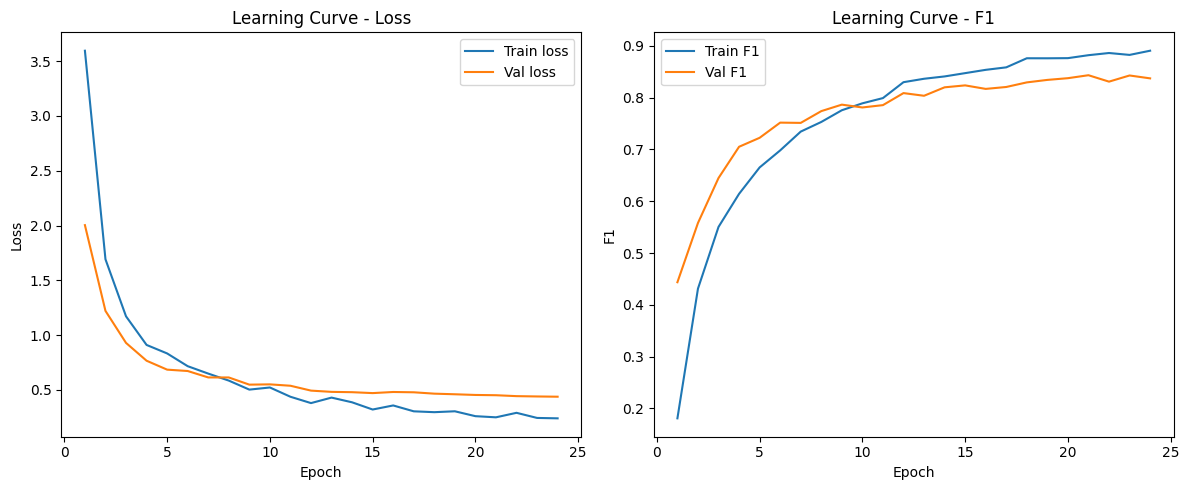

In [85]:
epochs_range = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, history["train_loss"], label="Train loss")
plt.plot(epochs_range, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, history["train_f1"], label="Train F1")
plt.plot(epochs_range, history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Learning Curve - F1")
plt.legend()

plt.tight_layout()
plt.show()

Optimum: 10 - 15 epochs

### Test Evaluate

In [86]:
test_loss, test_acc, test_f1, test_labels, test_preds = evaluate_e5(
    model_e5, test_loader_e5, criterion_e5
)
print("E5 TEST acc:", test_acc, "TEST F1:", test_f1)

E5 TEST acc: 0.9466803383747757 TEST F1: 0.848701450460896


#### Mistake analysis

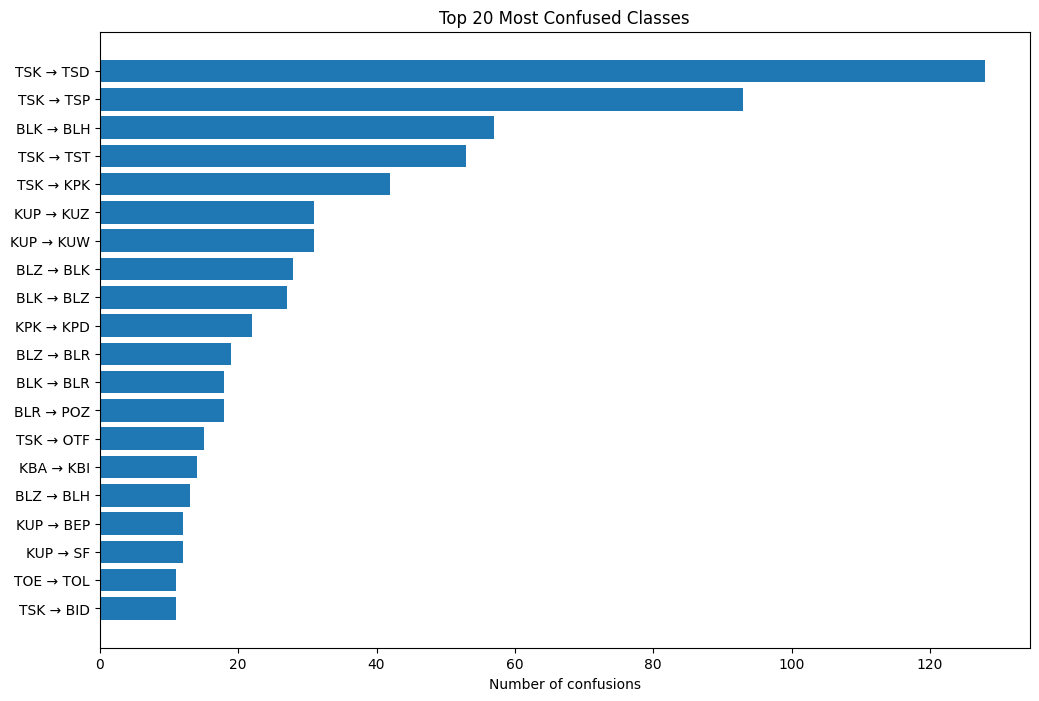

In [87]:
cm = confusion_matrix(
    test_labels,
    test_preds,
    labels=np.arange(num_classes)
)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

top_confusions = []
for i in range(num_classes):
    for j in range(num_classes):

        if cm_no_diag[i, j] > 0:
            top_confusions.append({
                "true": id2label[i],
                "pred": id2label[j],
                "count": cm_no_diag[i, j]
            })

top_confusions = (
    pd.DataFrame(top_confusions)
    .sort_values("count", ascending=False)
)

top20 = top_confusions.head(20)

plt.figure(figsize=(12,8))
labels = [
    f"{t} → {p}"
    for t, p in zip(top20["true"], top20["pred"])
]

plt.barh(labels, top20["count"])
plt.xlabel("Number of confusions")
plt.title("Top 20 Most Confused Classes")
plt.gca().invert_yaxis()
plt.show()

In [88]:
#Examples of mistaken observations

X_test_reset = (
    df_model.iloc[idx_test]
    .reset_index(drop=True)
    .copy()
)

X_test_reset["pred"] = [
    id2label[p]
    for p in test_preds
]

X_test_reset["true"] = [
    id2label[t]
    for t in test_labels
]

errors = X_test_reset[
    X_test_reset["pred"] != X_test_reset["true"]
]

sample = errors.sample(
    min(8, len(errors)),
    random_state=SEED
)

print("Examples of mistaken observations \n")
for _, r in sample.iterrows():
    print("=" * 100)
    print(f"[TRUE = {r.true}]")
    print(f"[PRED = {r.pred}]")
    print("TEXT:")
    print(
        r.text[:500]
        .replace("\n", " ")
    )
    print()

Examples of mistaken observations 

[TRUE = TSK]
[PRED = TSP]
TEXT:
Lightweight Tank fashion fit tee, pre-shrunk, no sideseams, shoulder-to-shoulder tape, double-needle sleeve and bottom hem, narrow 1x1 rib collarette, UV-protection and environmentally-friendly 100% Cotton

[TRUE = PAS]
[PRED = PAK]
TEXT:
Midsize umbrella FARE Gearshift Convenient automatic function for a quick opening, high-quality Windproof PLUS system for maximum frame flexibility in stormy conditions, flexible fibreglass ribs, water-saving coloured polyester pongee waterSAVE cover material made from recycled plastics, with waterSAVE label on the closing strap, dull silver gear stick handle with promotional labelling option (f. e. shifting gate), handle with special finish parts and integrated push button, higher corrosion pro

[TRUE = KUP]
[PRED = KUW]
TEXT:
Factory - Detachable Sleeve Blouson Jacket Fleece lined collar with drawcord. Concealed hood with elasticated drawcord. Elasticated drawcord at armholes. Two f

#### UMAP e5 embedding representation

In [93]:
model_e5.eval()

hidden_vectors = []
hidden_labels = []
with torch.no_grad():
    for batch in test_loader_e5:
        features = batch["features"].to(DEVICE)
        labels = batch["label"]
        logits, hidden = model_e5(features, return_embeddings=True)
        hidden_vectors.append(hidden.cpu().numpy())
        hidden_labels.append(labels.numpy())

hidden_vectors = np.concatenate(hidden_vectors)
hidden_labels = np.concatenate(hidden_labels)

sample_size = 3000
idx_sample = np.random.choice(
    len(hidden_vectors),
    size=min(sample_size, len(hidden_vectors)),
    replace=False
)

hidden_sample = hidden_vectors[idx_sample]
hidden_labels_sample = hidden_labels[idx_sample]
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)
hidden_umap = reducer.fit_transform(hidden_sample)

/mnt/Dane_Ubuntu/AI Projects/E-commerce_category_classification/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [94]:
# Plotly
top_classes = (
    pd.Series(hidden_labels_sample)
    .value_counts()
    .head(15)
    .index
)

mask = np.isin(hidden_labels_sample,top_classes)

plot_x = hidden_umap[mask]
plot_y = hidden_labels_sample[mask]

plot_df = pd.DataFrame({
    "x": plot_x[:,0],
    "y": plot_x[:,1],
    "label_id": plot_y,
})

plot_df["label"] = plot_df["label_id"].map(id2label)

fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color="label",
    hover_data=["label"],
    title="UMAP — Hidden Representations",
    width=1200,
    height=900,
)
fig.update_traces(marker=dict(size=5))
fig.show()

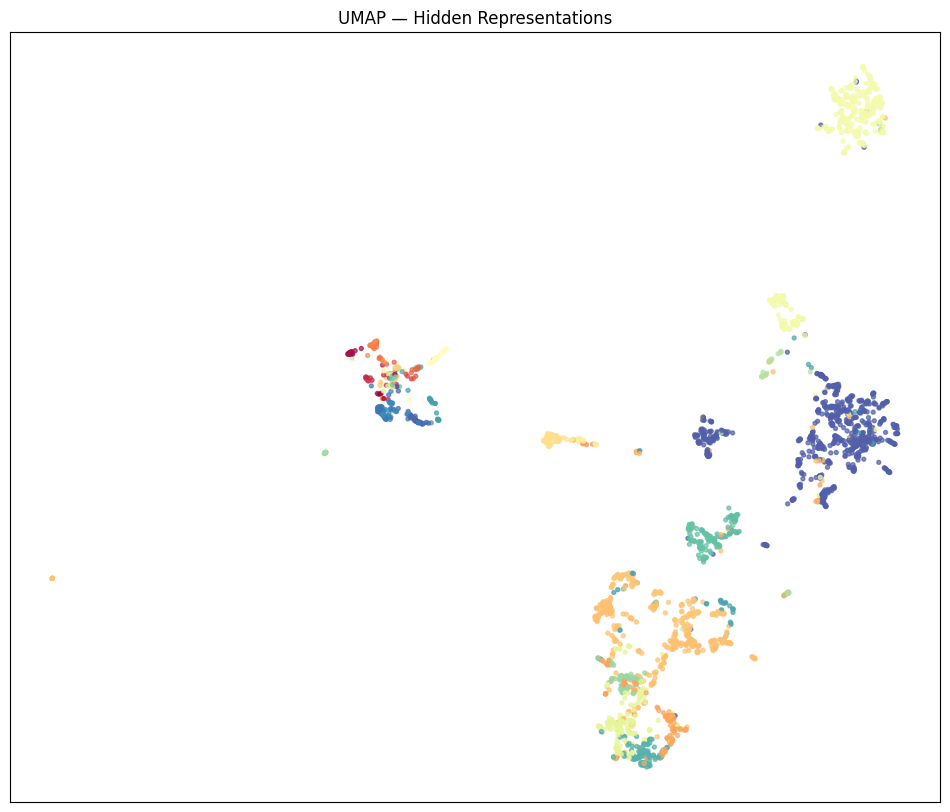

In [90]:
# Matplotlib
plt.figure(figsize=(12,10))
plt.scatter(
    hidden_umap[:,0],
    hidden_umap[:,1],
    c=hidden_labels_sample,
    cmap="Spectral",
    alpha=0.7,
    s=8
)

plt.title("UMAP — Hidden Representations")
plt.xticks([])
plt.yticks([])
plt.show()